In [2]:
import os
print(os.getcwd())

c:\Users\meetc\Desktop\fintech-sentiment-analyzer


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv('data/financial_news_events.csv')
print(df.shape)
print(df.isnull().sum())
df.head()

(3024, 12)
Date                      0
Headline                148
Source                    0
Market_Event              0
Market_Index              0
Index_Change_Percent    161
Trading_Volume            0
Sentiment               171
Sector                    0
Impact_Level              0
Related_Company           0
News_Url                153
dtype: int64


,Date,Headline,Source,Market_Event,Market_Index,Index_Change_Percent,Trading_Volume,Sentiment,Sector,Impact_Level,Related_Company,News_Url
0,2025-05-21,Nikkei 225 index benefits from a weaker yen,Times of India,Commodity Price Shock,DAX,3.52,166.45,NaN,Technology,High,Goldman Sachs,https://timesofindia.indiatimes.com/business/m...
1,2025-05-18,Government subsidy program gives a lift to the...,Financial Times,Central Bank Meeting,Shanghai Composite,-3.39,57.61,NaN,Retail,Low,ExxonMobil,https://timesofindia.indiatimes.com/business/m...
2,2025-06-25,New housing data release shows a slowdown in m...,The Hindu Business Line,Consumer Confidence Report,Shanghai Composite,-0.05,403.22,Neutral,Retail,Medium,Boeing,https://www.moneycontrol.com/us-markets/sp-500
3,2025-07-21,Massive stock buyback program announced by a c...,The Economist,Commodity Price Shock,NSE Nifty,-2.29,100.11,Positive,Consumer Goods,Low,Samsung Electronics,https://www.cnbc.com/2025/09/automotive-indust...
4,2025-07-23,Government spending bill is expected to stimul...,The Motley Fool,Inflation Data Release,Nasdaq Composite,-3.97,438.22,Negative,Consumer Goods,Low,JP Morgan Chase,https://www.bloomberg.com/australia/asx-200-pe...


In [6]:
# Drop rows where critical columns are null
df_clean = df.dropna(subset=['Sentiment', 'Index_Change_Percent','Headline']).copy()

print("Rows after cleaning:", len(df_clean))
print("Dropped rows:", len(df) - len(df_clean))

#convert date column to datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

#confirm
print(df_clean.dtypes)
print(df_clean.isnull().sum())

Rows after cleaning: 2570
Dropped rows: 454
Date                    datetime64[ns]
Headline                        object
Source                          object
Market_Event                    object
Market_Index                    object
Index_Change_Percent           float64
Trading_Volume                 float64
Sentiment                       object
Sector                          object
Impact_Level                    object
Related_Company                 object
News_Url                        object
dtype: object
Date                      0
Headline                  0
Source                    0
Market_Event              0
Market_Index              0
Index_Change_Percent      0
Trading_Volume            0
Sentiment                 0
Sector                    0
Impact_Level              0
Related_Company           0
News_Url                127
dtype: int64


In [7]:
#Sentiment distribution
fig = px.pie(df_clean,
                names='Sentiment',
                title='Overall Sentiment Distribution',
                color_discrete_map={'Positive':'green', 'Negative':'red', 'Neutral':'gray'})
fig.show()
             

In [12]:
#Sentiment vs Average Index Change
sentiment_index_change = df_clean.groupby('Sentiment')['Index_Change_Percent'].mean().reset_index()
fig2 = px.bar(sentiment_index_change, x='Sentiment', y='Index_Change_Percent',
             title='Average Index Change by Sentiment',
             color='Sentiment',
             color_discrete_map={
                 'Positive':'green', 
                 'Negative':'red',
                 'Neutral':'gray'},
             text='Index_Change_Percent')
fig2.update_traces(texttemplate='%{text:.2f}%', textposition='outside')
fig2.update_layout(yaxis_title='Avg Index Change (%)', showlegend=False)
fig2.show()

In [15]:
# Sector-wise Sentiment Distribution
sector_sentiment = df_clean.groupby(['Sector', 'Sentiment']).size().reset_index(name='Count')
fig3 = px.bar(sector_sentiment, x='Sector', y='Count', color='Sentiment',
             title='Sentiment Distribution by Sector',
             color_discrete_map={
                 'Positive':'green', 
                 'Negative':'red',
                 'Neutral':'gray'},
                 barmode='group')
fig3.update_layout(xaxis_tickangle=-45, height=500)
fig3.show()

In [16]:
# India Focus - NSE Niifty + BSE Sensex only
df_india = df_clean[df_clean['Market_Index'].isin(['NSE Nifty', 'BSE Sensex'])]
print("India rows:", len(df_india))
fig4 = px.bar(df_india, x='Sentiment', y='Index_Change_Percent', color='Sentiment',
            facet_col='Market_Index',
            title='Sentiment vs Market Movement - NSE Nifty and BSE Sensex',
            color_discrete_map={
                 'Positive':'green', 
                 'Negative':'red',
                 'Neutral':'gray'})
fig4.update_layout(height=500, showlegend=False)
fig4.show()

India rows: 251


In [18]:
india_df = df_clean[df_clean['Market_Index'].isin(['NSE Nifty', 'BSE Sensex'])]
print("India rows:", len(india_df))

India rows: 251


C:\Users\meetc\AppData\Local\Temp\ipykernel_26084\299621401.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\meetc\AppData\Local\Temp\ipykernel_26084\299621401.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




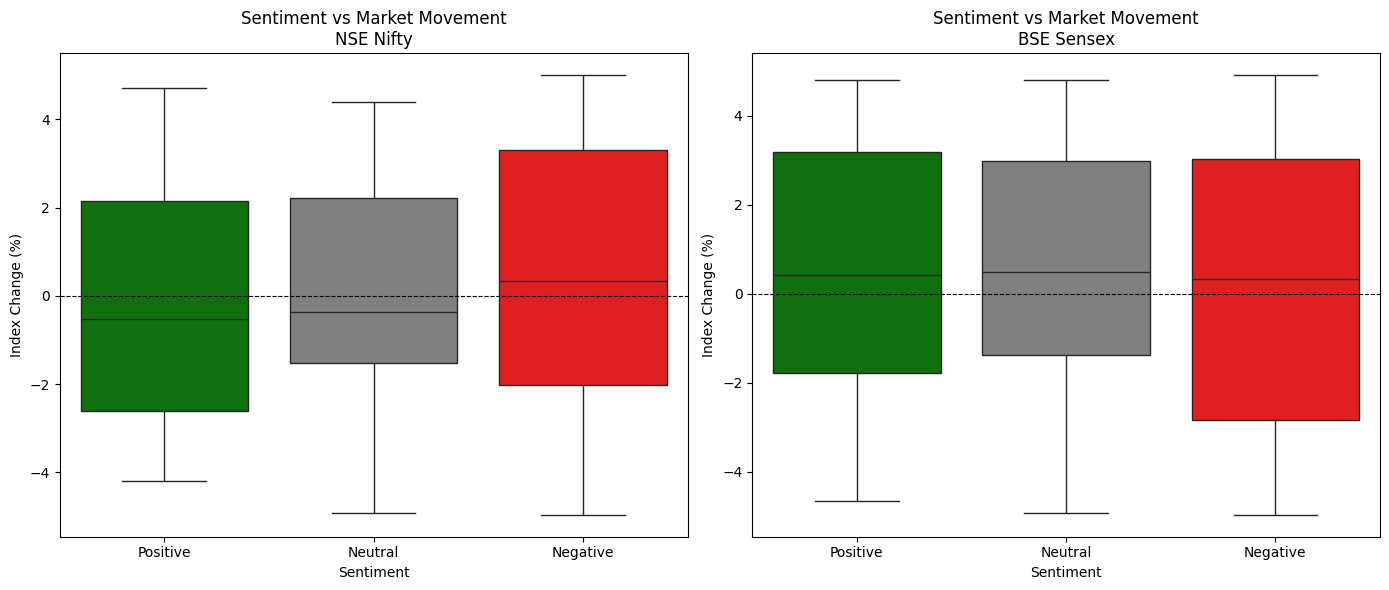

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, index in zip(axes, ['NSE Nifty', 'BSE Sensex']):
    data = india_df[india_df['Market_Index'] == index]
    sns.boxplot(data=data, x='Sentiment', y='Index_Change_Percent',
                order=['Positive', 'Neutral', 'Negative'],
                palette={'Positive': 'green', 'Neutral': 'gray', 'Negative': 'red'},
                ax=ax)
    ax.set_title(f'Sentiment vs Market Movement\n{index}')
    ax.set_xlabel('Sentiment')
    ax.set_ylabel('Index Change (%)')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

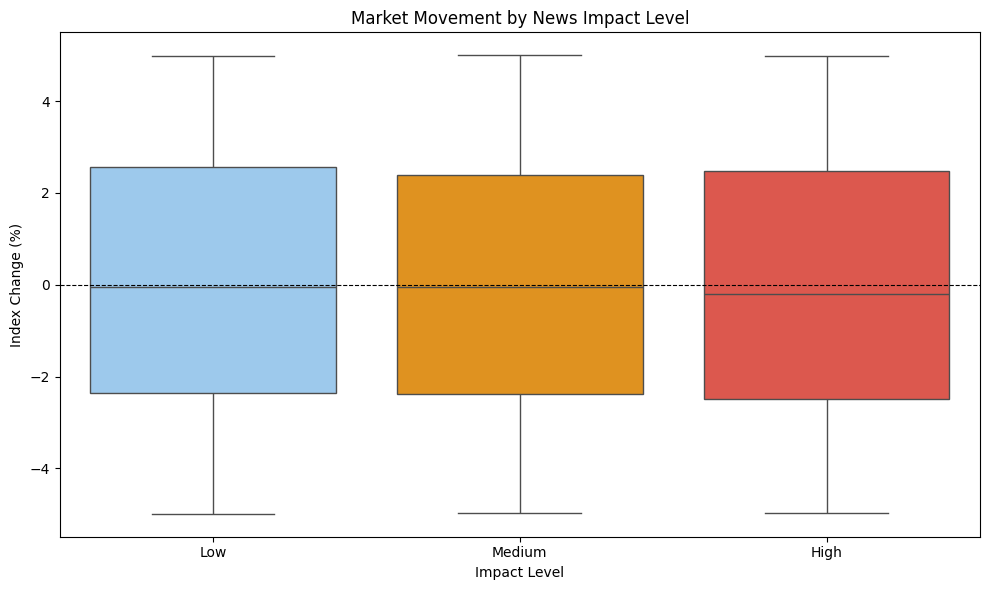

In [20]:
# Impact Level vs Index Change
fig5, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=df_clean, 
            x='Impact_Level', 
            y='Index_Change_Percent',
            order=['Low', 'Medium', 'High'],
            palette={'Low': '#90CAF9', 'Medium': '#FF9800', 'High': '#F44336'},
            hue='Impact_Level',
            legend=False,
            ax=ax)

ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Market Movement by News Impact Level')
ax.set_xlabel('Impact Level')
ax.set_ylabel('Index Change (%)')

plt.tight_layout()
plt.show()

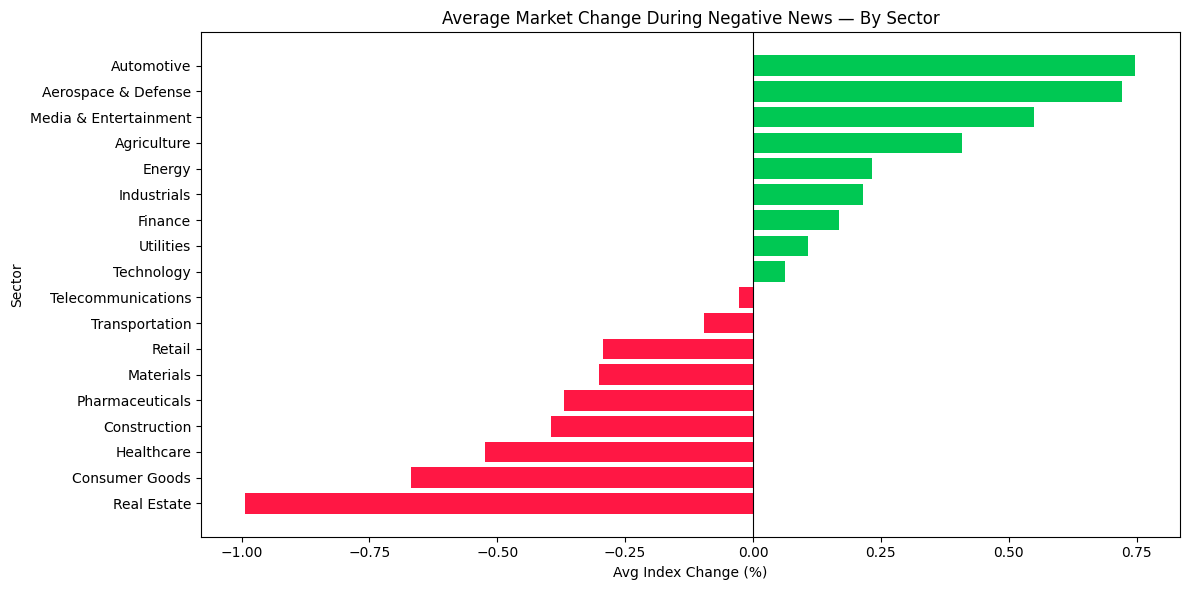

In [21]:
# Most Negatively Impacted Sectors
neg_df = df_clean[df_clean['Sentiment'] == 'Negative']
sector_avg = neg_df.groupby('Sector')['Index_Change_Percent'].mean().sort_values().reset_index()

fig6, ax = plt.subplots(figsize=(12, 6))
colors = ['#FF1744' if x < 0 else '#00C853' for x in sector_avg['Index_Change_Percent']]

ax.barh(sector_avg['Sector'], sector_avg['Index_Change_Percent'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Average Market Change During Negative News — By Sector')
ax.set_xlabel('Avg Index Change (%)')
ax.set_ylabel('Sector')

plt.tight_layout()
plt.show()

In [25]:
# Key Findings Summary
print("*" * 55)
print("   FINTECH SENTIMENT ANALYZER — KEY FINDINGS")
print("*" * 55)

print("\n1. SENTIMENT DISTRIBUTION")
print(df_clean['Sentiment'].value_counts().to_string())

print("\n2. AVG MARKET CHANGE BY SENTIMENT")
print(df_clean.groupby('Sentiment')['Index_Change_Percent']
      .mean().round(3).to_string())

print("\n3. MOST NEGATIVELY IMPACTED SECTOR (Negative News)")
neg = df_clean[df_clean['Sentiment']=='Negative']
print(neg.groupby('Sector')['Index_Change_Percent']
      .mean().idxmin(), "—",
      neg.groupby('Sector')['Index_Change_Percent']
      .mean().min().round(3), "%")

print("\n4. INDIA FOCUS — NSE Nifty & BSE Sensex rows:")
print(len(india_df))

print("\n5. HIGH IMPACT NEWS — Avg market change:")
print(df_clean[df_clean['Impact_Level']=='High']
      ['Index_Change_Percent'].mean().round(3), "%")
print("=" * 55)

*******************************************************
   FINTECH SENTIMENT ANALYZER — KEY FINDINGS
*******************************************************

1. SENTIMENT DISTRIBUTION
Sentiment
Negative    884
Neutral     846
Positive    840

2. AVG MARKET CHANGE BY SENTIMENT
Sentiment
Negative   -0.062
Neutral     0.114
Positive   -0.107

3. MOST NEGATIVELY IMPACTED SECTOR (Negative News)
Real Estate — -0.992 %

4. INDIA FOCUS — NSE Nifty & BSE Sensex rows:
251

5. HIGH IMPACT NEWS — Avg market change:
-0.058 %
